In [4]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print(result.stdout)
else:
    print('❌ No GPU detected! Go to Settings → Accelerator → GPU P100 and restart.')

Fri May 29 04:38:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             27W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import sys

print('Installing segment-anything and MONAI...')
!pip install -q segment-anything
!pip install -q monai
!pip install -q scikit-image tqdm

# Clone MONAI VISTA (for reference architecture — we use SAM directly for inference)
import os
if not os.path.exists('/kaggle/working/VISTA'):
    !git clone --quiet https://github.com/Project-MONAI/VISTA.git /kaggle/working/VISTA

sys.path.insert(0, '/kaggle/working/VISTA/vista2d')
print('✅ All packages installed.')

Installing segment-anything and MONAI...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 37.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.6 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but yo

In [6]:
import os

CHECKPOINT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

SAM_CHECKPOINT = f'{CHECKPOINT_DIR}/sam_vit_b_01ec64.pth'
SAM_MODEL_TYPE = 'vit_b'   # Lightest: vit_b | Balanced: vit_l | Best (slow): vit_h

if not os.path.exists(SAM_CHECKPOINT):
    print('Downloading SAM ViT-B checkpoint (~375 MB)...')
    !wget -q --show-progress \
        https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth \
        -O {SAM_CHECKPOINT}
    print('✅ SAM checkpoint downloaded.')
else:
    print('✅ Checkpoint already present.')

print(f'Size: {os.path.getsize(SAM_CHECKPOINT) / 1e6:.1f} MB')

/kaggle/working/che 100%[===================>] 357.67M  55.9MB/s    in 6.5s    
✅ SAM checkpoint downloaded.
Size: 375.0 MB


In [9]:
import os
import glob
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Dataset root on Kaggle ──
DATASET_ROOT = '/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed'

# ── Only these two classes, only CROPPED subfolder ──
TARGET_CLASSES = {
    'Koilocytotic': 'im_Koilocytotic',
    'Dyskeratotic': 'im_Dyskeratotic',
}

# ── Collect image paths ──
image_records = []   # list of dicts: {path, filename, cell_class}

for label, folder_name in TARGET_CLASSES.items():
    # The dataset nests: im_Koilocytotic/im_Koilocytotic/CROPPED/
    cropped_dir = os.path.join(DATASET_ROOT, folder_name, folder_name, 'CROPPED')
    
    if not os.path.isdir(cropped_dir):
        # Fallback: search recursively for any CROPPED folder under this class
        matches = glob.glob(os.path.join(DATASET_ROOT, folder_name, '**', 'CROPPED'), recursive=True)
        cropped_dir = matches[0] if matches else None
    
    if cropped_dir and os.path.isdir(cropped_dir):
        exts = ('*.bmp', '*.BMP', '*.png', '*.PNG', '*.jpg', '*.JPG')
        for ext in exts:
            for fpath in sorted(glob.glob(os.path.join(cropped_dir, ext))):
                image_records.append({
                    'path': fpath,
                    'filename': os.path.basename(fpath),
                    'cell_class': label,
                })
        print(f'  {label}: found {len([r for r in image_records if r["cell_class"]==label])} cropped images in {cropped_dir}')
    else:
        print(f'  ⚠️  Could not find CROPPED folder for {label}. Checking full tree...')
        # Last resort: find all .bmp under this class folder
        for fpath in sorted(glob.glob(os.path.join(DATASET_ROOT, folder_name, '**', '*.bmp'), recursive=True)):
            image_records.append({
                'path': fpath,
                'filename': os.path.basename(fpath),
                'cell_class': label,
            })

print(f'\n✅ Total cropped cell images loaded: {len(image_records)}')
print(f'   Koilocytotic : {sum(1 for r in image_records if r["cell_class"]=="Koilocytotic")}')
print(f'   Dyskeratotic : {sum(1 for r in image_records if r["cell_class"]=="Dyskeratotic")}')

  Koilocytotic: found 825 cropped images in /kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Koilocytotic/im_Koilocytotic/CROPPED
  Dyskeratotic: found 813 cropped images in /kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Dyskeratotic/im_Dyskeratotic/CROPPED

✅ Total cropped cell images loaded: 1638
   Koilocytotic : 825
   Dyskeratotic : 813


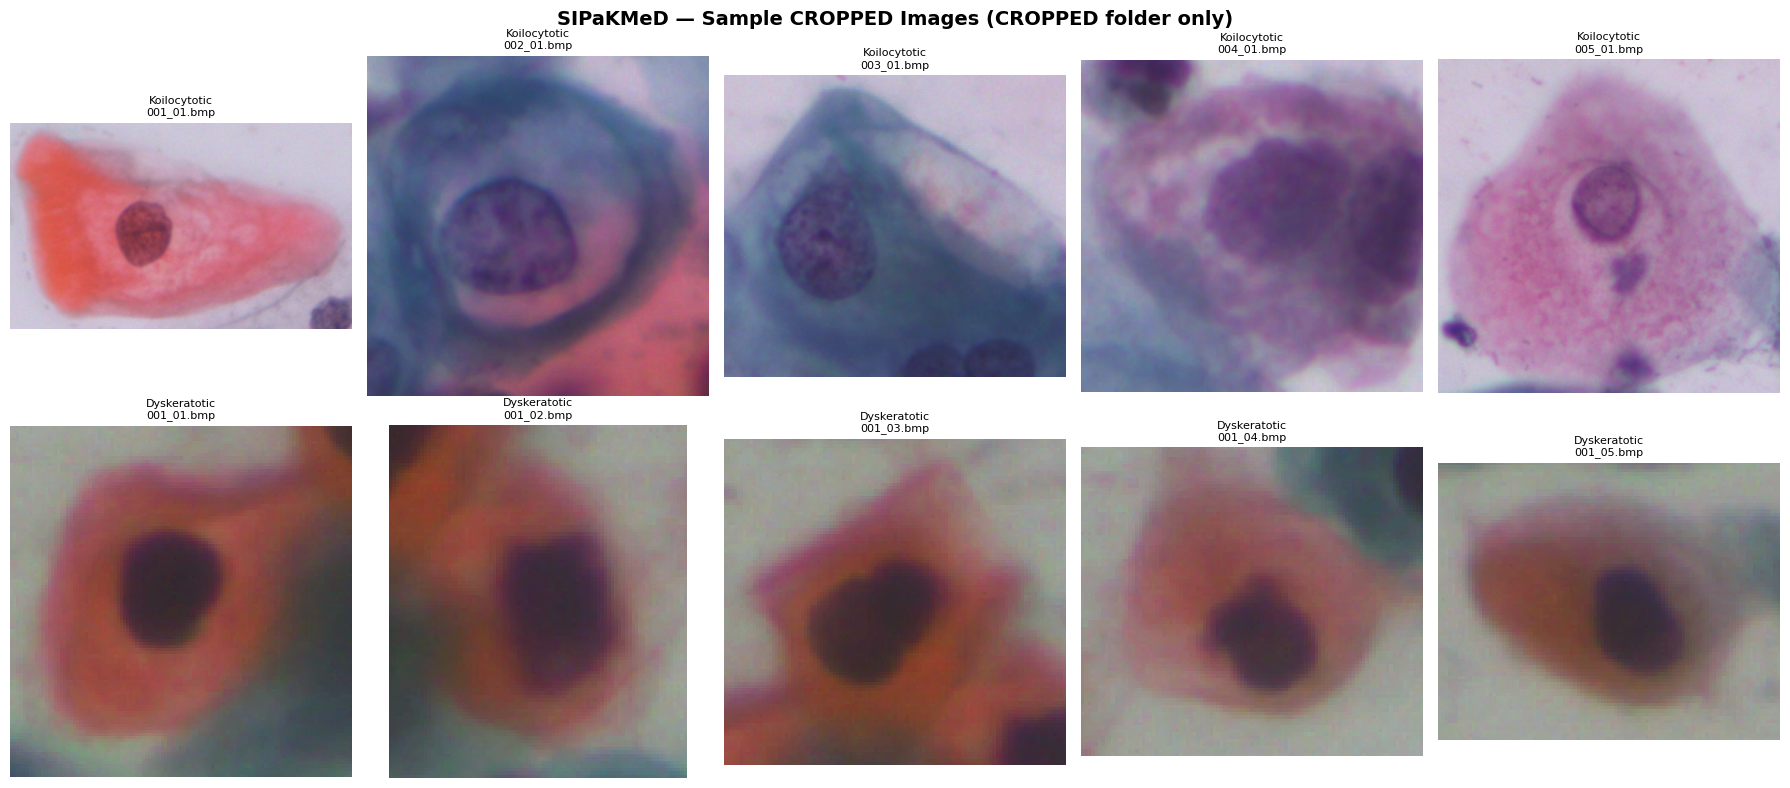

In [10]:
def load_rgb(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f'Cannot load {path}')
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('SIPaKMeD — Sample CROPPED Images (CROPPED folder only)', fontsize=14, fontweight='bold')

for row, label in enumerate(['Koilocytotic', 'Dyskeratotic']):
    samples = [r for r in image_records if r['cell_class'] == label][:5]
    for col, rec in enumerate(samples):
        img = load_rgb(rec['path'])
        axes[row][col].imshow(img)
        axes[row][col].set_title(f'{label}\n{rec["filename"]}', fontsize=8)
        axes[row][col].axis('off')
    # Fill empty slots if fewer than 5
    for col in range(len(samples), 5):
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_preview.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
import torch
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

DEVICE = 'cpu'
print(f'Device: {DEVICE}')

# Load SAM
sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
sam.to('cpu')
sam.eval()

# Prompted predictor — used for centre-point and hollow-point prompts
predictor = SamPredictor(sam)

# Automatic generator — for comparison / fallback
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=16,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=80,
)

print('\n✅ VISTA2D / SAM model loaded and ready.')

Device: cpu

✅ VISTA2D / SAM model loaded and ready.


In [16]:
import matplotlib.patches as mpatches
from skimage import measure, morphology
from tqdm.notebook import tqdm
import json
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────
# FUNCTION 1: Segment full cell boundary
# ─────────────────────────────────────────────────
def segment_cell(image_rgb, predictor):
    """
    Segment the full cell using a centre-point SAM prompt.
    For cropped SIPaKMeD images, the cell of interest is centred.
    Returns: (best_mask [H,W bool], confidence_score)
    """
    h, w = image_rgb.shape[:2]
    predictor.set_image(image_rgb)

    # Centre point as primary prompt
    centre = np.array([[w // 2, h // 2]])
    labels = np.array([1])  # 1 = foreground

    masks, scores, logits = predictor.predict(
        point_coords=centre,
        point_labels=labels,
        multimask_output=True,
    )

    # If centre-point returns a tiny mask, try bounding-box fallback
    best_idx = np.argmax(scores)
    best_mask = masks[best_idx]

    # Quality check — mask must cover at least 5% of image
    coverage = best_mask.sum() / (h * w)
    if coverage < 0.05:
        # Retry with a slightly off-centre grid of 5 points
        offsets = np.array([
            [w//2,     h//2],
            [w//2-10,  h//2],
            [w//2+10,  h//2],
            [w//2,     h//2-10],
            [w//2,     h//2+10],
        ])
        lbs = np.ones(5, dtype=int)
        masks2, scores2, _ = predictor.predict(
            point_coords=offsets,
            point_labels=lbs,
            multimask_output=True,
        )
        best_idx2 = np.argmax(scores2)
        if scores2[best_idx2] > scores[best_idx]:
            best_mask = masks2[best_idx2]
            scores[best_idx] = scores2[best_idx2]

    return best_mask, float(scores[best_idx])


# ─────────────────────────────────────────────────
# FUNCTION 2: Segment hollow / perinuclear halo
# ─────────────────────────────────────────────────
def segment_hollow(image_rgb, predictor, cell_mask):
    """
    Detect and segment the koilocytic perinuclear halo (hollow space).

    Algorithm:
    1. Mask the image to the cell region only
    2. Find pixels darker than 65% of mean cell intensity
    3. Use the centroid of the largest dark blob as a SAM positive prompt
    4. Use a bright cytoplasm point as SAM negative prompt
    5. Constrain result to inside the cell mask

    Returns: (sam_hollow_mask, threshold_dark_mask)
    """
    h, w = image_rgb.shape[:2]
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    # Apply cell mask to restrict search
    gray_inside = gray.copy().astype(float)
    gray_inside[~cell_mask] = 999   # Push background to high value

    # Intensity threshold inside the cell
    cell_intensities = gray[cell_mask]
    if len(cell_intensities) == 0:
        return None, None

    mean_int = cell_intensities.mean()
    dark_thresh = mean_int * 0.65   # Pixels darker than 65% of mean

    dark_mask = (gray_inside < dark_thresh) & cell_mask
    dark_mask = morphology.remove_small_objects(dark_mask.astype(bool), min_size=60)
    dark_mask = morphology.binary_closing(dark_mask, morphology.disk(3))

    if not dark_mask.any():
        return None, None

    # Find connected components; take the largest dark region
    labeled = measure.label(dark_mask)
    regions = sorted(measure.regionprops(labeled), key=lambda r: r.area, reverse=True)
    if not regions:
        return None, None

    largest = regions[0]
    cy, cx = int(largest.centroid[0]), int(largest.centroid[1])

    # Find a bright cytoplasm pixel for negative prompt
    bright_thresh = mean_int * 1.1
    bright_pixels = np.argwhere((gray > bright_thresh) & cell_mask & ~dark_mask)

    predictor.set_image(image_rgb)

    if len(bright_pixels) > 0:
        # Pick brightest cytoplasm pixel near the edge of the cell (not centre)
        bp = bright_pixels[len(bright_pixels) // 2]   # median position
        point_coords = np.array([[cx, cy], [bp[1], bp[0]]])
        point_labels = np.array([1, 0])   # pos, neg
    else:
        point_coords = np.array([[cx, cy]])
        point_labels = np.array([1])

    masks, scores, _ = predictor.predict(
        point_coords=point_coords,
        point_labels=point_labels,
        multimask_output=True,
    )

    best_idx = np.argmax(scores)
    sam_hollow = masks[best_idx] & cell_mask

    # Sanity: hollow must be smaller than the cell
    if sam_hollow.sum() > cell_mask.sum() * 0.85:
        # SAM grabbed the whole cell — fall back to threshold mask
        return dark_mask, dark_mask

    return sam_hollow, dark_mask


# ─────────────────────────────────────────────────
# FUNCTION 3: Morphological features
# ─────────────────────────────────────────────────
def compute_features(image_rgb, cell_mask, hollow_mask, filename, cell_class):
    """Compute morphological and intensity features for the segmented cell."""
    features = {'filename': filename, 'cell_class': cell_class}
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    if cell_mask is not None and cell_mask.any():
        lbl = measure.label(cell_mask.astype(np.uint8))
        props = measure.regionprops(lbl)
        if props:
            p = max(props, key=lambda x: x.area)
            features['cell_area_px']       = int(p.area)
            features['cell_perimeter']     = round(p.perimeter, 2)
            features['cell_eccentricity']  = round(p.eccentricity, 4)
            features['cell_solidity']      = round(p.solidity, 4)
            features['cell_mean_intensity']= round(float(gray[cell_mask].mean()), 2)

    if hollow_mask is not None and hollow_mask.any():
        lbl2 = measure.label(hollow_mask.astype(np.uint8))
        hprops = measure.regionprops(lbl2)
        if hprops:
            hp = max(hprops, key=lambda x: x.area)
            features['hollow_area_px']          = int(hp.area)
            features['hollow_eccentricity']     = round(hp.eccentricity, 4)
            features['hollow_mean_intensity']   = round(float(gray[hollow_mask].mean()), 2)

            if 'cell_area_px' in features:
                ratio = hp.area / features['cell_area_px']
                features['halo_to_cell_ratio'] = round(ratio, 4)
                # Koilocytes typically have halo ratio > 0.20
                features['likely_koilocyte']   = bool(ratio > 0.20)

        # Cytoplasm = cell minus hollow
        cyto = cell_mask & ~hollow_mask if cell_mask is not None else None
        if cyto is not None and cyto.any():
            features['cytoplasm_mean_intensity'] = round(float(gray[cyto].mean()), 2)
            features['halo_contrast'] = round(
                features.get('cytoplasm_mean_intensity', 0) - features.get('hollow_mean_intensity', 0), 2
            )

    return features


print('✅ Helper functions defined.')

✅ Helper functions defined.


In [17]:
def visualise_result(image_rgb, cell_mask, hollow_mask, dark_mask,
                     filename, cell_class, features, save_path=None):
    """
    4-panel figure:
    [Original] [Cell mask overlay] [Hollow/halo overlay] [Combined + contour]
    """
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    title = f'[{cell_class}]  {filename}'
    if 'halo_to_cell_ratio' in features:
        title += f'  |  Halo ratio: {features["halo_to_cell_ratio"]:.3f}'
    fig.suptitle(title, fontsize=12, fontweight='bold')

    # ── Panel 1: Original ──
    axes[0].imshow(image_rgb)
    axes[0].set_title('Original (CROPPED)', fontsize=10)
    axes[0].axis('off')

    # ── Panel 2: Cell mask ──
    ov1 = image_rgb.copy().astype(np.float32) / 255.0
    if cell_mask is not None:
        ov1[cell_mask] = ov1[cell_mask] * 0.45 + np.array([0.15, 0.55, 1.0]) * 0.55
    axes[1].imshow(ov1)
    axes[1].set_title(f'Cell Mask\n(SAM ViT-B)', fontsize=10)
    axes[1].axis('off')

    # ── Panel 3: Hollow / halo ──
    ov2 = image_rgb.copy().astype(np.float32) / 255.0
    if hollow_mask is not None and hollow_mask.any():
        ov2[hollow_mask] = ov2[hollow_mask] * 0.35 + np.array([1.0, 0.25, 0.1]) * 0.65
    if dark_mask is not None and dark_mask.any() and (hollow_mask is None or not hollow_mask.any()):
        ov2[dark_mask] = ov2[dark_mask] * 0.35 + np.array([1.0, 0.7, 0.0]) * 0.65
    axes[2].imshow(ov2)
    label = 'Hollow/Halo (SAM)' if (hollow_mask is not None and hollow_mask.any()) else 'Dark Region (threshold)'
    axes[2].set_title(label, fontsize=10)
    axes[2].axis('off')

    # ── Panel 4: Combined with contour ──
    ov3 = image_rgb.copy().astype(np.float32) / 255.0
    if cell_mask is not None:
        kern = np.ones((3, 3), np.uint8)
        dilated = cv2.dilate(cell_mask.astype(np.uint8), kern) - cell_mask.astype(np.uint8)
        ov3[dilated.astype(bool)] = [0.1, 0.55, 1.0]
    if hollow_mask is not None and hollow_mask.any():
        ov3[hollow_mask] = ov3[hollow_mask] * 0.4 + np.array([1.0, 0.2, 0.1]) * 0.6

    patch_cell   = mpatches.Patch(color=[0.1, 0.55, 1.0], label='Cell boundary')
    patch_hollow = mpatches.Patch(color=[1.0, 0.3, 0.1], label='Halo/hollow')
    axes[3].imshow(ov3)
    axes[3].legend(handles=[patch_cell, patch_hollow], fontsize=8, loc='lower right')
    axes[3].set_title('Combined', fontsize=10)
    axes[3].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    plt.close()


print('✅ Visualisation function defined.')

✅ Visualisation function defined.


Running segmentation on 40 images...



Segmenting:   0%|          | 0/40 [00:00<?, ?it/s]

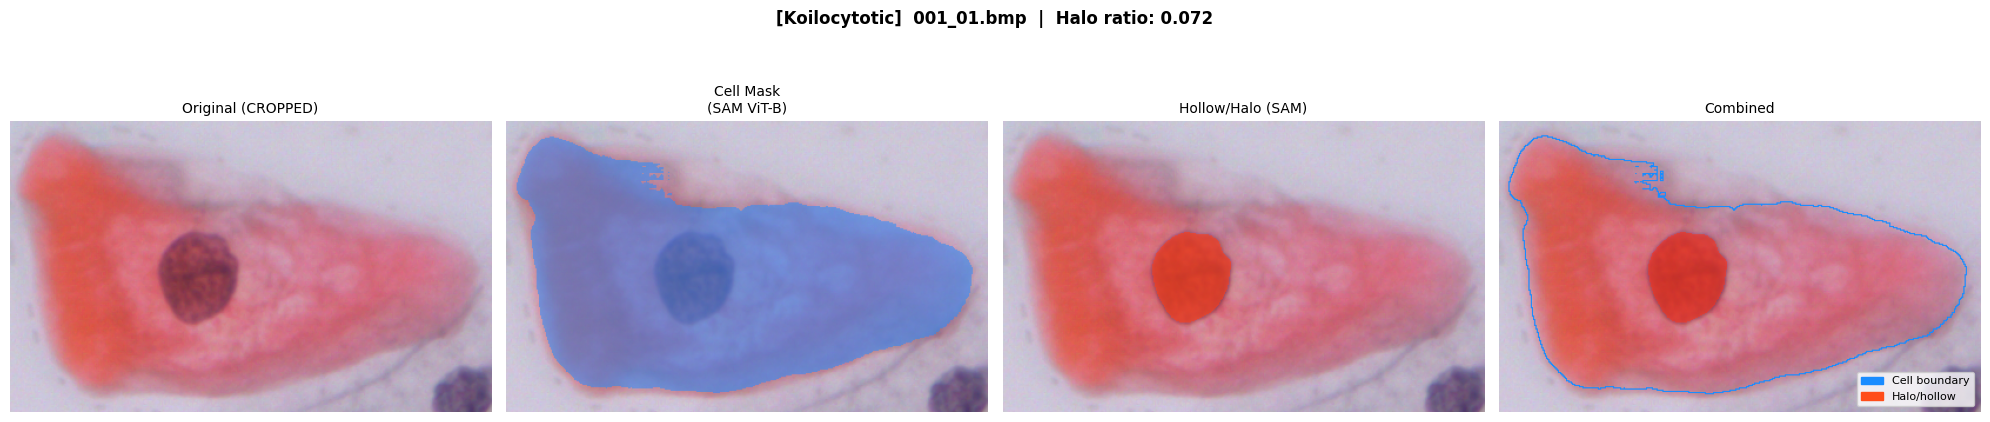

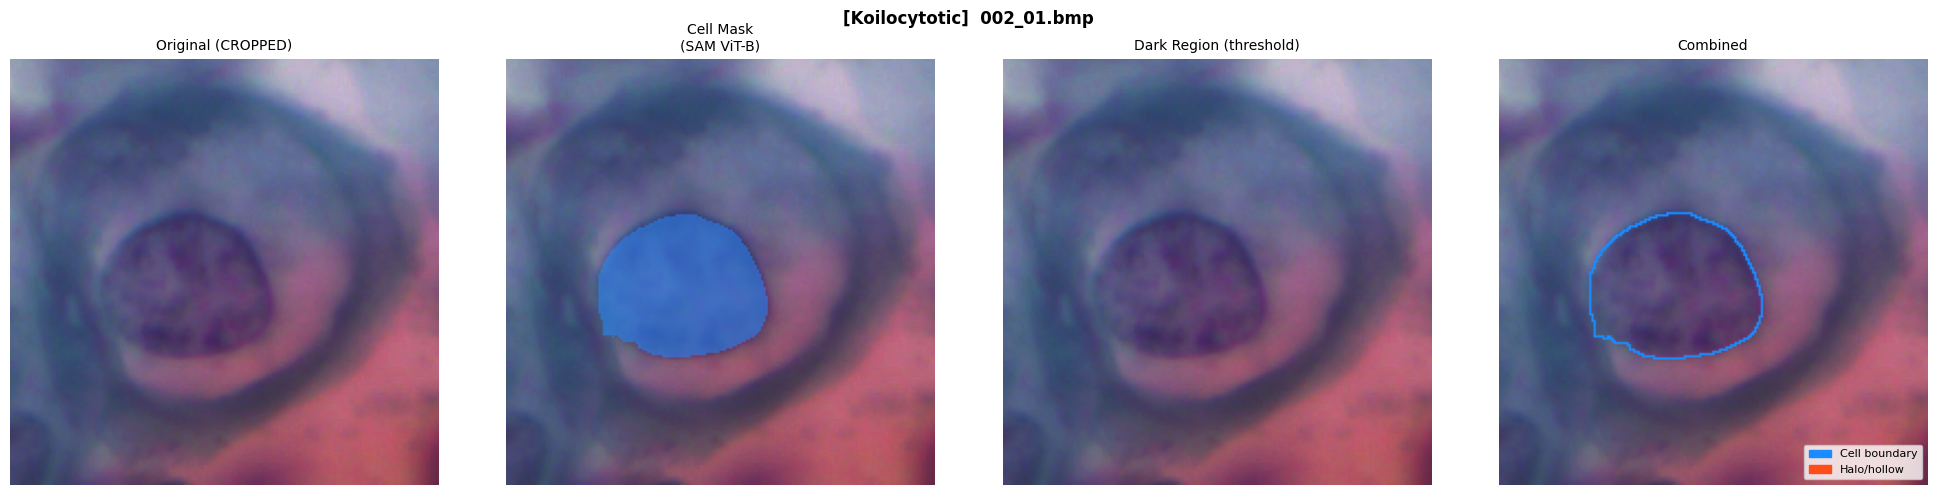

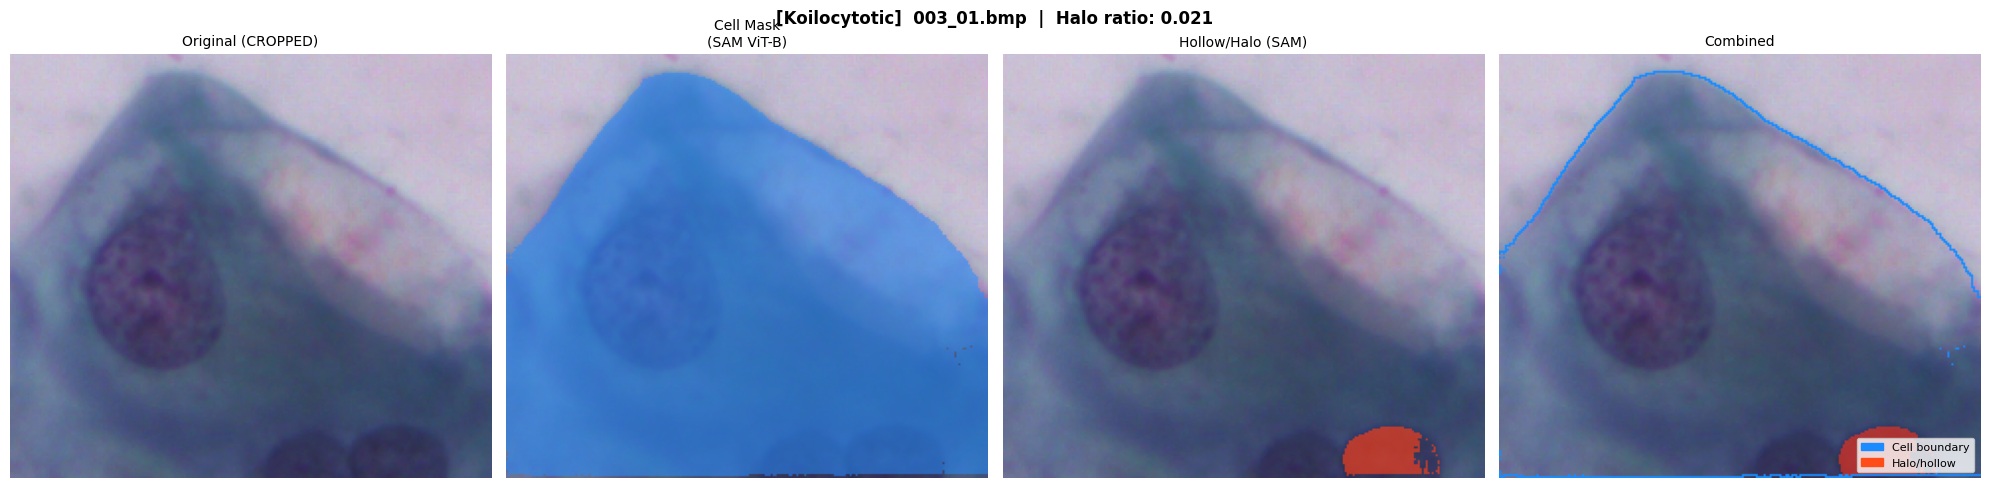

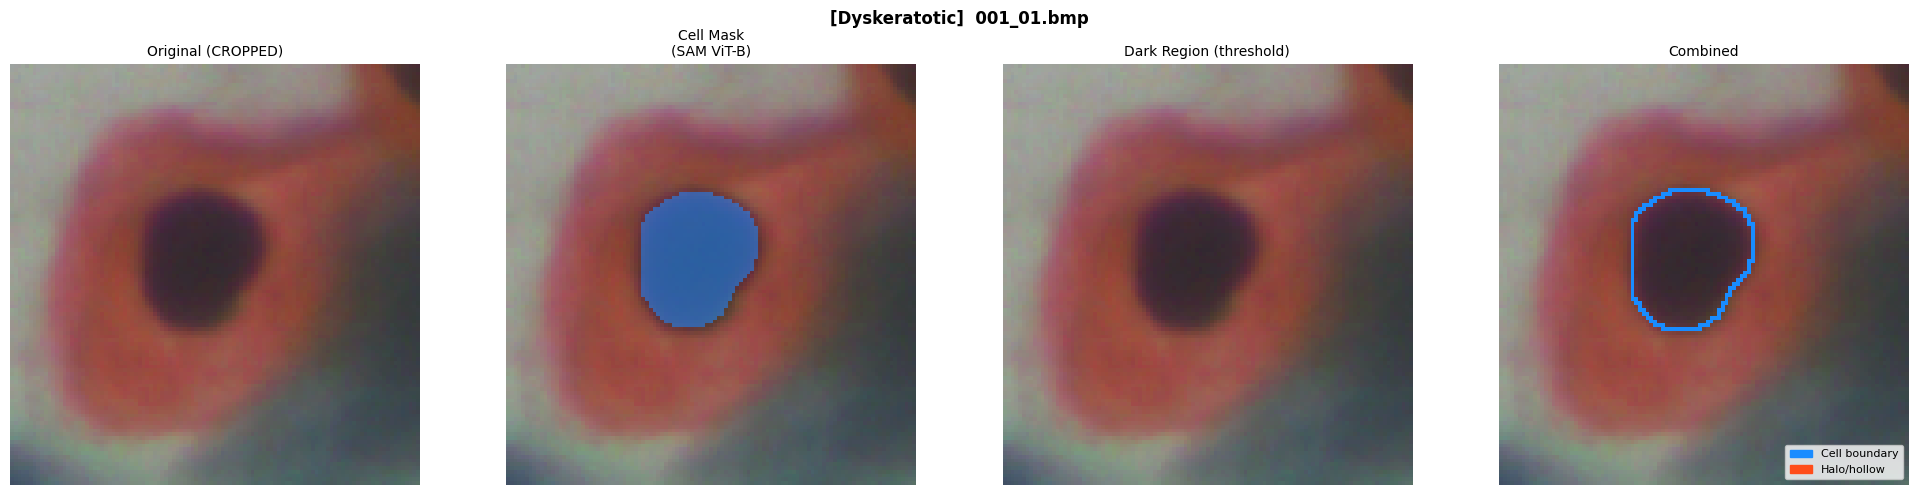

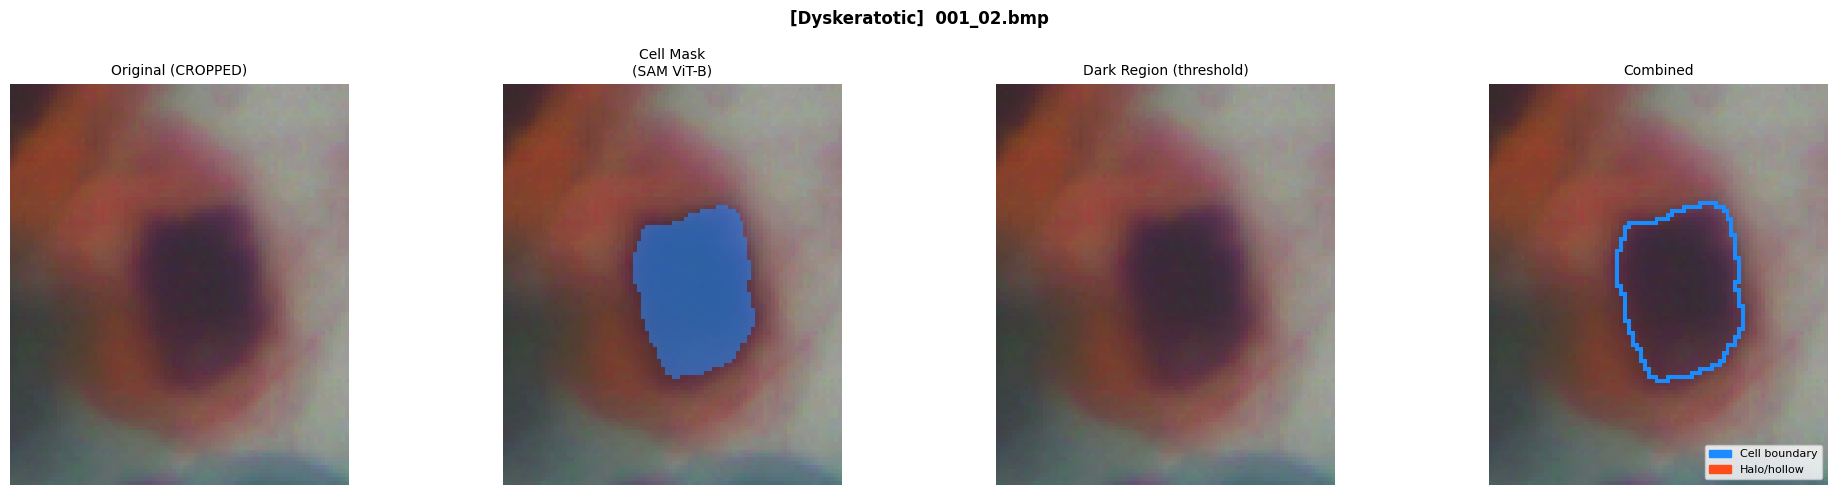

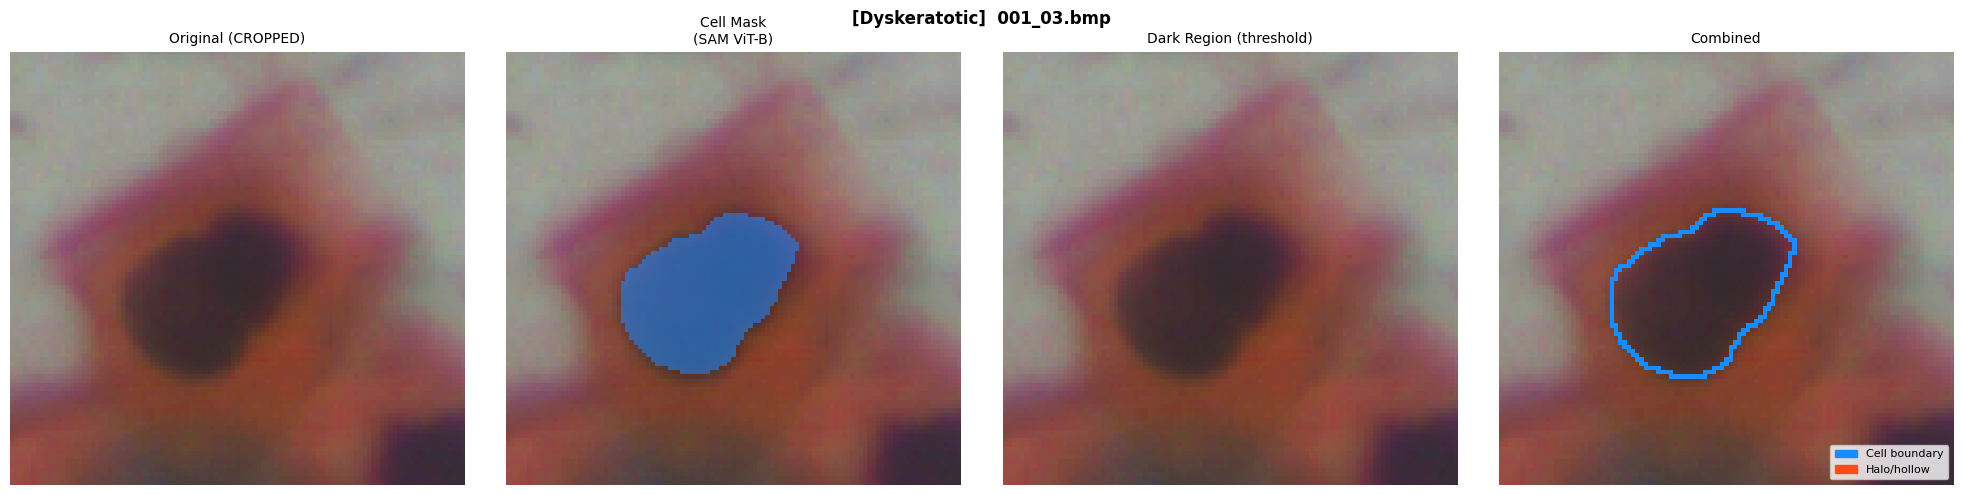


✅ Segmentation complete. 40 images processed.
Outputs saved to: /kaggle/working/output


In [18]:
# ── Config ──────────────────────────────────────
MAX_PER_CLASS  = 20    # Set to None to process ALL images (~793 total)
                       # Start with 20 to verify, then set to None for full run
SAVE_MASKS     = True  # Save binary mask PNGs to /kaggle/working/output/
SHOW_PLOTS     = True  # Display 4-panel plots inline
SHOW_FIRST_N   = 3     # Show detailed plots for first N images only (saves time)
# ────────────────────────────────────────────────

OUTPUT_DIR = '/kaggle/working/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

results_summary = []
plot_count = {'Koilocytotic': 0, 'Dyskeratotic': 0}

# Filter records to MAX_PER_CLASS
records_to_run = []
for cls in ['Koilocytotic', 'Dyskeratotic']:
    class_recs = [r for r in image_records if r['cell_class'] == cls]
    if MAX_PER_CLASS:
        class_recs = class_recs[:MAX_PER_CLASS]
    records_to_run.extend(class_recs)

print(f'Running segmentation on {len(records_to_run)} images...\n')

for rec in tqdm(records_to_run, desc='Segmenting'):
    fpath      = rec['path']
    fname      = rec['filename']
    cell_class = rec['cell_class']
    stem       = os.path.splitext(fname)[0]
    class_out  = os.path.join(OUTPUT_DIR, cell_class)
    os.makedirs(class_out, exist_ok=True)

    try:
        # ── Load image ──
        image_rgb = load_rgb(fpath)

        # ── Segment full cell ──
        cell_mask, cell_score = segment_cell(image_rgb, predictor)

        # ── Segment hollow space (koilocytic halo) ──
        hollow_mask, dark_mask = segment_hollow(image_rgb, predictor, cell_mask)

        # ── Compute features ──
        feats = compute_features(image_rgb, cell_mask, hollow_mask, fname, cell_class)
        feats['sam_cell_score'] = round(cell_score, 4)
        results_summary.append(feats)

        # ── Save masks ──
        if SAVE_MASKS:
            if cell_mask is not None:
                cv2.imwrite(f'{class_out}/{stem}_cell_mask.png',
                            (cell_mask * 255).astype(np.uint8))
            if hollow_mask is not None and hollow_mask.any():
                cv2.imwrite(f'{class_out}/{stem}_hollow_mask.png',
                            (hollow_mask * 255).astype(np.uint8))
            if dark_mask is not None and dark_mask.any():
                cv2.imwrite(f'{class_out}/{stem}_dark_mask.png',
                            (dark_mask * 255).astype(np.uint8))

        # ── Visualise (first SHOW_FIRST_N per class only) ──
        if SHOW_PLOTS and plot_count[cell_class] < SHOW_FIRST_N:
            vis_path = f'{class_out}/{stem}_vis.png'
            visualise_result(image_rgb, cell_mask, hollow_mask, dark_mask,
                             fname, cell_class, feats, save_path=vis_path)
            plot_count[cell_class] += 1

    except Exception as e:
        import traceback
        print(f'\n❌ Error — {fname}: {e}')
        traceback.print_exc()

# Save summary
with open(f'{OUTPUT_DIR}/results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2, default=str)

print(f'\n✅ Segmentation complete. {len(results_summary)} images processed.')
print(f'Outputs saved to: {OUTPUT_DIR}')

In [19]:
import pandas as pd

df = pd.DataFrame(results_summary)

# Reorder columns
col_order = ['filename', 'cell_class', 'cell_area_px', 'hollow_area_px',
             'halo_to_cell_ratio', 'likely_koilocyte',
             'cell_eccentricity', 'cell_solidity',
             'hollow_mean_intensity', 'cytoplasm_mean_intensity',
             'halo_contrast', 'sam_cell_score']
df = df[[c for c in col_order if c in df.columns]]

print('=== Results Table (first 10 rows) ===')
print(df.head(10).to_string(index=False))

print('\n=== Per-Class Statistics ===')
numeric_cols = ['cell_area_px', 'halo_to_cell_ratio', 'cell_solidity',
                'halo_contrast', 'cell_eccentricity']
numeric_cols = [c for c in numeric_cols if c in df.columns]
print(df.groupby('cell_class')[numeric_cols].mean().round(4))

# Save CSV
csv_path = f'{OUTPUT_DIR}/results_summary.csv'
df.to_csv(csv_path, index=False)
print(f'\n✅ Full table saved to {csv_path}')

=== Results Table (first 10 rows) ===
  filename   cell_class  cell_area_px  hollow_area_px  halo_to_cell_ratio likely_koilocyte  cell_eccentricity  cell_solidity  hollow_mean_intensity  cytoplasm_mean_intensity  halo_contrast  sam_cell_score
001_01.bmp Koilocytotic         54186          3906.0              0.0721            False             0.8819         0.9309                  90.64                    142.19          51.55          0.9831
002_01.bmp Koilocytotic          3928             NaN                 NaN              NaN             0.5585         0.9791                    NaN                       NaN            NaN          0.9489
003_01.bmp Koilocytotic         39244           814.0              0.0207            False             0.6314         0.9891                  56.80                     99.96          43.16          0.9694
004_01.bmp Koilocytotic         19101          1315.0              0.0688            False             0.3039         0.9948                  

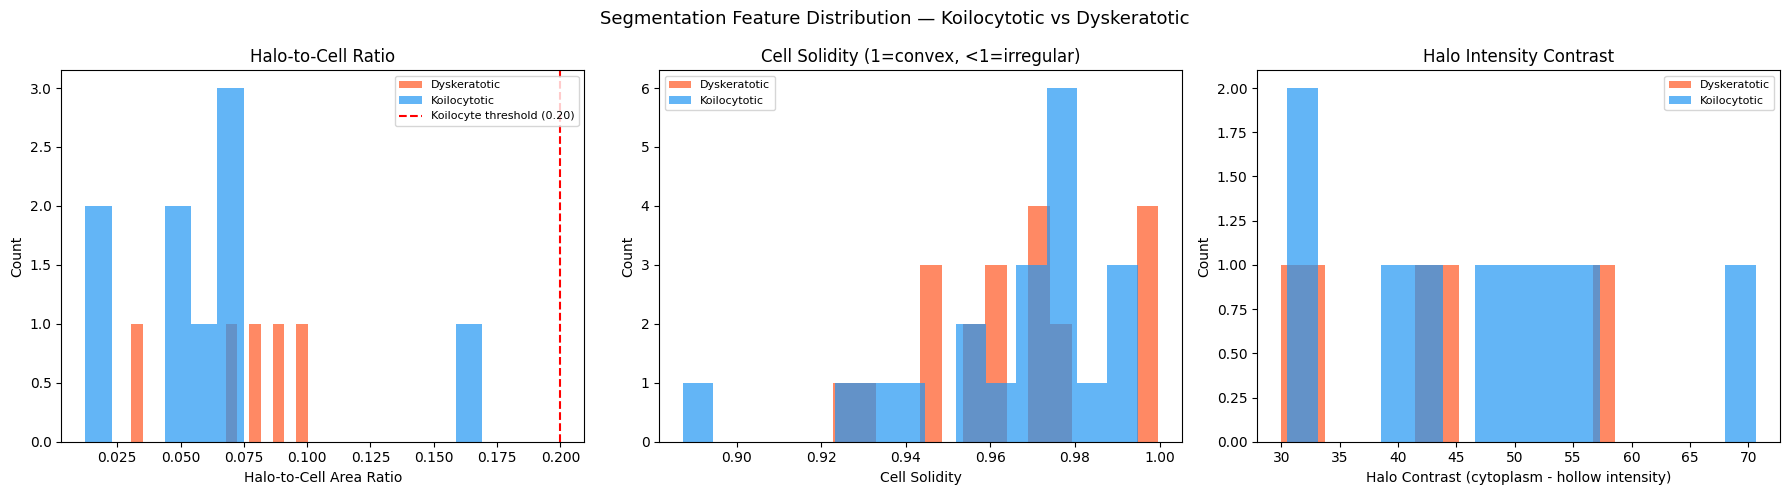

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Segmentation Feature Distribution — Koilocytotic vs Dyskeratotic', fontsize=13)

colors = {'Koilocytotic': '#2196F3', 'Dyskeratotic': '#FF5722'}

# Plot 1: Halo-to-cell ratio
if 'halo_to_cell_ratio' in df.columns:
    for cls, grp in df.groupby('cell_class'):
        axes[0].hist(grp['halo_to_cell_ratio'].dropna(), bins=15,
                     alpha=0.7, label=cls, color=colors.get(cls, 'gray'))
    axes[0].axvline(0.20, color='red', linestyle='--', linewidth=1.5, label='Koilocyte threshold (0.20)')
    axes[0].set_xlabel('Halo-to-Cell Area Ratio')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Halo-to-Cell Ratio')
    axes[0].legend(fontsize=8)

# Plot 2: Cell solidity
if 'cell_solidity' in df.columns:
    for cls, grp in df.groupby('cell_class'):
        axes[1].hist(grp['cell_solidity'].dropna(), bins=15,
                     alpha=0.7, label=cls, color=colors.get(cls, 'gray'))
    axes[1].set_xlabel('Cell Solidity')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Cell Solidity (1=convex, <1=irregular)')
    axes[1].legend(fontsize=8)

# Plot 3: Halo contrast
if 'halo_contrast' in df.columns:
    for cls, grp in df.groupby('cell_class'):
        axes[2].hist(grp['halo_contrast'].dropna(), bins=15,
                     alpha=0.7, label=cls, color=colors.get(cls, 'gray'))
    axes[2].set_xlabel('Halo Contrast (cytoplasm - hollow intensity)')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Halo Intensity Contrast')
    axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

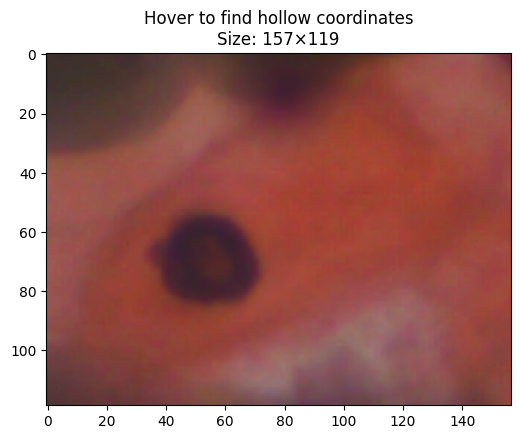

In [26]:
# ── Edit these ──────────────────────────────────
MANUAL_IMAGE_PATH = '/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Dyskeratotic/im_Dyskeratotic/CROPPED/002_04.bmp'
HOLLOW_X = None   # X pixel of hollow (None = auto-detect)
HOLLOW_Y = None   # Y pixel of hollow (None = auto-detect)
# ─────────────────────────────────────────────────

if os.path.exists(MANUAL_IMAGE_PATH):
    image_rgb = load_rgb(MANUAL_IMAGE_PATH)
    h, w = image_rgb.shape[:2]

    # Show image to identify coordinates
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_rgb)
    ax.set_title(f'Hover to find hollow coordinates\nSize: {w}×{h}')
    if HOLLOW_X and HOLLOW_Y:
        ax.plot(HOLLOW_X, HOLLOW_Y, 'r*', markersize=18, label=f'Hollow prompt ({HOLLOW_X},{HOLLOW_Y})')
        ax.legend()
    plt.show()


    if HOLLOW_X and HOLLOW_Y:
        # Run SAM with manual prompt
        predictor.set_image(image_rgb)
        masks_m, scores_m, _ = predictor.predict(
            point_coords=np.array([[HOLLOW_X, HOLLOW_Y]]),
            point_labels=np.array([1]),
            multimask_output=True,
        )
        fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
        for i in range(3):
            ov = image_rgb.copy().astype(np.float32) / 255.0
            ov[masks_m[i]] = ov[masks_m[i]] * 0.4 + np.array([1.0, 0.2, 0.1]) * 0.6
            axes2[i].imshow(ov)
            axes2[i].set_title(f'Candidate {i+1} | score={scores_m[i]:.3f}')
            axes2[i].axis('off')
        plt.suptitle('Manual hollow segmentation — choose best candidate')
        plt.show()
else:
    print(f'Image not found: {MANUAL_IMAGE_PATH}')
    print('Update MANUAL_IMAGE_PATH to a valid path from the dataset.')

Running automatic mask generation...
Total segments found: 2


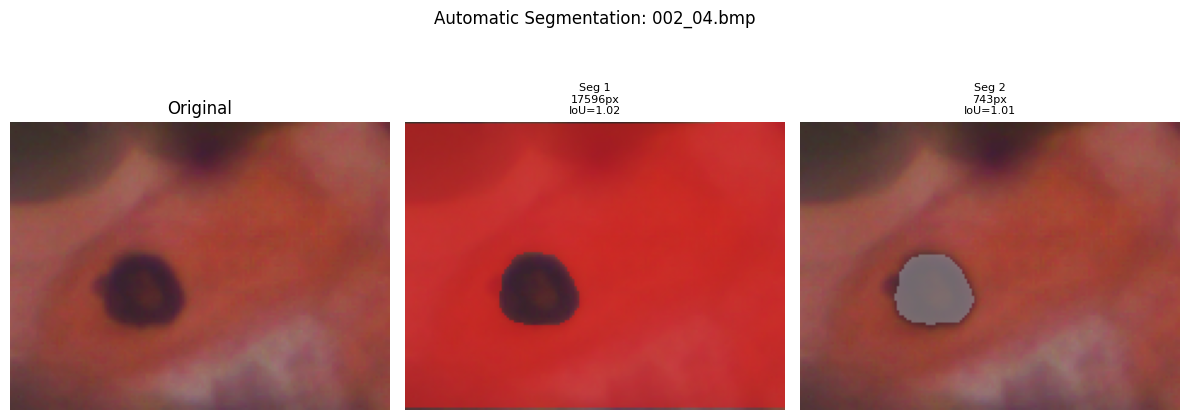

Seg 1 = largest (whole cell), Seg 2 = second largest (likely hollow or nucleus)


In [27]:
AUTO_IMAGE_PATH = '/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Dyskeratotic/im_Dyskeratotic/CROPPED/002_04.bmp'

if os.path.exists(AUTO_IMAGE_PATH):
    image_rgb = load_rgb(AUTO_IMAGE_PATH)
    print('Running automatic mask generation...')
    auto_masks = mask_generator.generate(image_rgb)
    auto_masks = sorted(auto_masks, key=lambda m: m['area'], reverse=True)
    print(f'Total segments found: {len(auto_masks)}')

    n_show = min(5, len(auto_masks))
    fig, axes = plt.subplots(1, n_show + 1, figsize=(4*(n_show+1), 5))
    axes[0].imshow(image_rgb)
    axes[0].set_title('Original')
    axes[0].axis('off')

    cmap = plt.cm.Set1(np.linspace(0, 1, n_show))
    for i in range(n_show):
        ov = image_rgb.copy().astype(np.float32) / 255.0
        m = auto_masks[i]['segmentation']
        ov[m] = ov[m]*0.4 + np.array(cmap[i][:3])*0.6
        axes[i+1].imshow(ov)
        axes[i+1].set_title(f'Seg {i+1}\n{auto_masks[i]["area"]}px\nIoU={auto_masks[i]["predicted_iou"]:.2f}', fontsize=8)
        axes[i+1].axis('off')

    plt.suptitle(f'Automatic Segmentation: {os.path.basename(AUTO_IMAGE_PATH)}', fontsize=12)
    plt.tight_layout()
    plt.show()
    print('Seg 1 = largest (whole cell), Seg 2 = second largest (likely hollow or nucleus)')
else:
    print(f'File not found: {AUTO_IMAGE_PATH}')

In [28]:
import zipfile

zip_out = '/kaggle/working/VISTA2D_segmentation_results.zip'

with zipfile.ZipFile(zip_out, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files_in_dir in os.walk(OUTPUT_DIR):
        for fname in files_in_dir:
            full = os.path.join(root, fname)
            arcname = os.path.relpath(full, '/kaggle/working')
            zf.write(full, arcname)

zip_size = os.path.getsize(zip_out) / 1e6
print(f'✅ ZIP created: {zip_out} ({zip_size:.1f} MB)')
print('\nOutput files in /kaggle/working/output/:')
for root, dirs, files_list in os.walk(OUTPUT_DIR):
    for f in files_list:
        full_path = os.path.join(root, f)
        size_kb = os.path.getsize(full_path) / 1024
        print(f'  {os.path.relpath(full_path, OUTPUT_DIR):60s}  {size_kb:.1f} KB')

✅ ZIP created: /kaggle/working/VISTA2D_segmentation_results.zip (1.9 MB)

Output files in /kaggle/working/output/:
  results_summary.json                                          13.1 KB
  results_summary.csv                                           2.8 KB
  feature_distributions.png                                     75.2 KB
  Dyskeratotic/001_02_vis.png                                   69.8 KB
  Dyskeratotic/003_03_cell_mask.png                             0.3 KB
  Dyskeratotic/002_08_cell_mask.png                             0.4 KB
  Dyskeratotic/003_05_cell_mask.png                             0.5 KB
  Dyskeratotic/002_03_hollow_mask.png                           0.2 KB
  Dyskeratotic/002_04_cell_mask.png                             0.4 KB
  Dyskeratotic/001_05_cell_mask.png                             0.3 KB
  Dyskeratotic/003_04_hollow_mask.png                           0.3 KB
  Dyskeratotic/002_07_cell_mask.png                             0.2 KB
  Dyskeratotic/001_02_cell_mas